# Kapitola 4: Vybraná diskrétní rozdělení

## 4.1 Alternativní rozdělení

**Značení:** $X \sim A(p)$  
**Parametry:** $p \in (0, 1)$  
**Nosič:** $X \in \{0, 1\}$  

**Pravděpodobnostní funkce:**  
$$
P(X = j) = p^j \cdot (1 - p)^{1-j}, \quad j = 0, 1
$$

**Střední hodnota:**  
$$
\mathbb{E}[X] = p
$$

**Rozptyl:**  
$$
\mathrm{Var}[X] = p(1 - p)
$$

**Poznámky:**  
- Rozdělení alternativního jevu, platí/neplatí.  
- Další názvy: Bernoulliho nebo nula-jedničkové rozdělení.


P(X = 0) ≈ 0.700
P(X = 1) ≈ 0.300


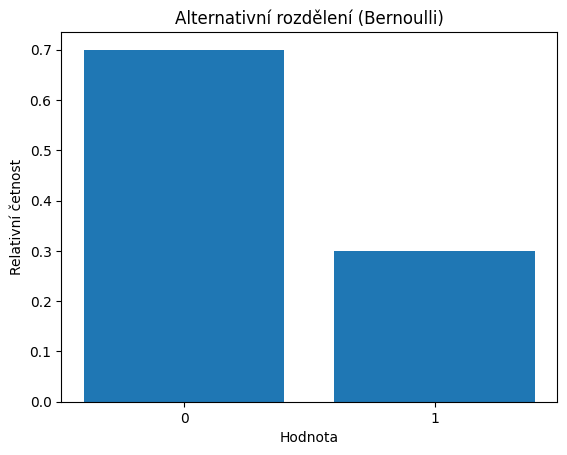

In [1]:
# Ukázka: generování alternativní náhodné veličiny
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import bernoulli

p = 0.3
n = 1000
samples = bernoulli.rvs(p, size=n)

# Výpočet relativní četnosti
unique, counts = np.unique(samples, return_counts=True)
for val, count in zip(unique, counts):
    print(f"P(X = {val}) ≈ {count/n:.3f}")

# Vizualizace
plt.bar(unique, counts/n, tick_label=["0", "1"])
plt.title("Alternativní rozdělení (Bernoulli)")
plt.xlabel("Hodnota")
plt.ylabel("Relativní četnost")
plt.show()

## 4.2 Binomické rozdělení

**Značení:** $X \sim \mathrm{Bi}(n, p)$  
**Parametry:** $n \in \mathbb{N},\ p \in (0, 1)$  
**Nosič:** $X \in \{0, 1, 2, \dots, n\}$  

**Pravděpodobnostní funkce:**  
$$
P(X = k) = \binom{n}{k} p^k (1 - p)^{n-k}, \quad k = 0, 1, \dots, n
$$

**Střední hodnota:**  
$$
\mathbb{E}[X] = n \cdot p
$$

**Rozptyl:**  
$$
\mathrm{Var}[X] = n \cdot p (1 - p)
$$


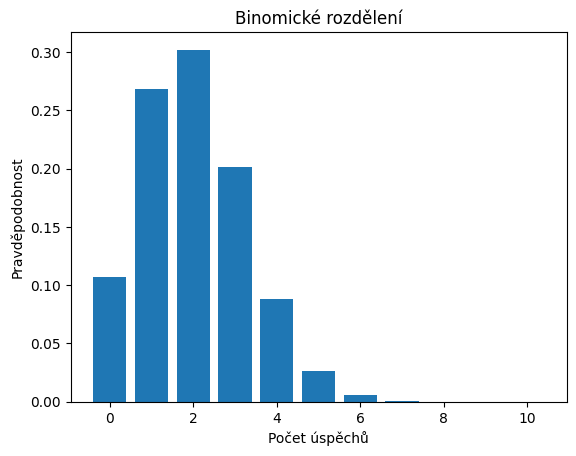

In [8]:
# Ukázka: binomické rozdělení
from scipy.stats import binom

n = 10
p = 0.2
x = np.arange(0, n+1)
pmf = binom.pmf(x, n, p)

plt.bar(x, pmf)
plt.title("Binomické rozdělení")
plt.xlabel("Počet úspěchů")
plt.ylabel("Pravděpodobnost")
plt.show()

## 4.3 Hypergeometrické rozdělení

**Značení:** $X \sim \mathrm{HG}(N, K, n)$  

**Parametry:**  
- $N$ - velikost populace  
- $K$ - počet úspěšných prvků  
- $n$ - velikost výběru  

**Nosič:**  
$$
X \in \{\max(0, n + K - N), \dots, \min(n, K)\}
$$

**Pravděpodobnostní funkce:**  
$$
P(X = k) = \frac{\binom{K}{k} \binom{N-K}{n-k}}{\binom{N}{n}}
$$

**Střední hodnota:**  
$$
\mathbb{E}[X] = n \cdot \frac{K}{N}
$$

**Rozptyl:**  
$$
\mathrm{Var}[X] = n \cdot \frac{K}{N} \cdot \left(1 - \frac{K}{N}\right) \cdot \frac{N - n}{N - 1}
$$


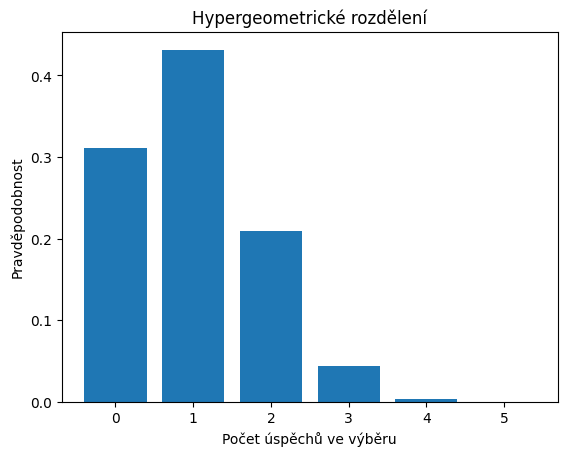

In [3]:
# Ukázka: hypergeometrické rozdělení
from scipy.stats import hypergeom

N = 50  # velikost populace
K = 10  # počet úspěšných prvků
n = 5   # velikost výběru
x = np.arange(0, n+1)
pmf = hypergeom.pmf(x, N, K, n)

plt.bar(x, pmf)
plt.title("Hypergeometrické rozdělení")
plt.xlabel("Počet úspěchů ve výběru")
plt.ylabel("Pravděpodobnost")
plt.show()

In [ ]:

import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from scipy.stats import hypergeom, binom
from IPython.display import display

# Interaktivní ovládací prvky
N_slider = widgets.IntSlider(value=100, min=20, max=1000, step=10, description='Populace N')
K_slider = widgets.IntSlider(value=50, min=1, max=100, step=1, description='Úspěchy K')
n_slider = widgets.IntSlider(value=20, min=1, max=100, step=1, description='Výběr n')

def update_plot(N, K, n):
    # Hodnoty náhodné veličiny
    x = np.arange(0, n+1)

    # Hypergeometrické rozdělení
    hyper_pmf = hypergeom.pmf(x, N, K, n)

    # Binomické rozdělení s p = K / N
    p = K / N
    binom_pmf = binom.pmf(x, n, p)

    # Vykreslení pomocí Plotly
    fig = go.Figure()
    fig.add_trace(go.Bar(x=x, y=hyper_pmf, name='Hypergeometrické', marker_color='blue'))
    fig.add_trace(go.Bar(x=x, y=binom_pmf, name='Binomické', marker_color='red'))

    fig.update_layout(
        title=f'Porovnání rozdělení pro N={N}, K={K}, n={n}',
        xaxis_title='Počet úspěchů ve výběru',
        yaxis_title='Pravděpodobnost',
        barmode='overlay',
        bargap=0.1,
        template='plotly_white'
    )
    fig.show()

# Propojení ovládacích prvků s funkcí
widgets.interact(update_plot, N=N_slider, K=K_slider, n=n_slider)


interactive(children=(IntSlider(value=100, description='Populace N', max=1000, min=20, step=10), IntSlider(val…

<function __main__.update_plot(N, K, n)>

## 4.4 Poissonovo rozdělení

**Značení:** $X \sim \mathrm{Po}(\lambda)$  
**Parametry:** $\lambda > 0$  
**Nosič:** $X \in \{0, 1, 2, \dots\}$  

**Pravděpodobnostní funkce:**  
$$
P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \dots
$$

**Střední hodnota:**  
$$
\mathbb{E}[X] = \lambda
$$

**Rozptyl:**  
$$
\mathrm{Var}[X] = \lambda
$$


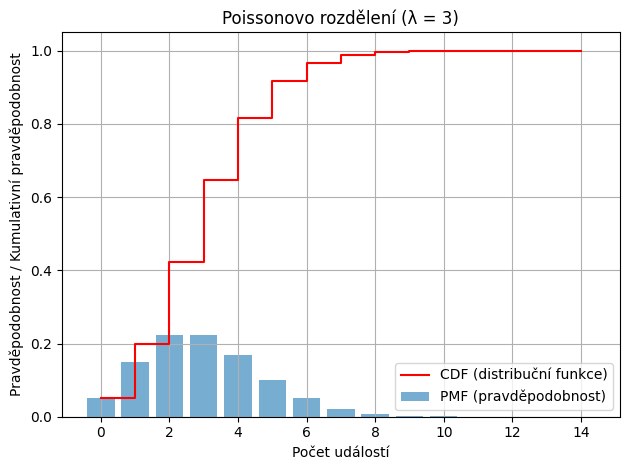

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parametry Poissonova rozdělení
lam = 3.0
x = np.arange(0, 15)

# Pravděpodobnostní funkce (PMF)
pmf = poisson.pmf(x, lam)

# Distribuční funkce (CDF)
cdf = poisson.cdf(x, lam)

# Vykreslení PMF jako sloupcový graf
plt.bar(x, pmf, alpha=0.6, label="PMF (pravděpodobnost)")

# Vykreslení CDF jako schodová funkce
plt.step(x, cdf, where='post', color='red', label="CDF (distribuční funkce)")

# Popisky a legenda
plt.title("Poissonovo rozdělení (λ = 3)")
plt.xlabel("Počet událostí")
plt.ylabel("Pravděpodobnost / Kumulativní pravděpodobnost")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import scipy.stats as stats
import ipywidgets as widgets
from IPython.display import display

# Interaktivní ovládací prvek pro velikost vzorku
n_slider = widgets.IntSlider(value=100, min=10, max=5000, step=10, description='Počet n:', style={'description_width': 'initial'}, continuous_update=False)

# Parametr Poissonova rozdělení
lam = 3.0

def update_plot(n):
    # Generování n hodnot z Poissonova rozdělení
    data = np.random.poisson(lam, n)
    x_vals = np.arange(0, max(data) + 1)

    # Teoretická PMF a CDF
    pmf = stats.poisson.pmf(x_vals, lam)
    cdf = stats.poisson.cdf(x_vals, lam)

    # Empirická distribuční funkce
    sorted_data = np.sort(data)
    ecdf_y = np.arange(1, n + 1) / n

    # Histogram vs PMF
    hist_counts = np.array([np.sum(data == x) for x in x_vals])
    hist_probs = hist_counts / n

    fig1 = go.Figure()
    fig1.add_trace(go.Bar(x=x_vals, y=hist_probs, name='Empirická pravděpodobnost', marker_color='blue'))
    fig1.add_trace(go.Scatter(x=x_vals, y=pmf, mode='lines+markers', name='Teoretická PMF', line=dict(color='red')))
    fig1.update_layout(title=f'Porovnání histogramu a teoretické PMF (n = {n})',
                       xaxis_title='x',
                       yaxis_title='Pravděpodobnost',
                       bargap=0.2)

    # ECDF vs CDF
    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=sorted_data, y=ecdf_y, mode='lines+markers', name='Empirická CDF', line=dict(color='blue')))
    fig2.add_trace(go.Scatter(x=x_vals, y=cdf, mode='lines+markers', name='Teoretická CDF', line=dict(color='red')))
    fig2.update_layout(title=f'Porovnání empirické a teoretické distribuční funkce (n = {n})',
                       xaxis_title='x',
                       yaxis_title='Distribuční funkce')

    fig1.show()
    fig2.show()

# Zobrazení interaktivního ovládacího prvku
widgets.interact(update_plot, n=n_slider)

interactive(children=(IntSlider(value=100, continuous_update=False, description='Počet n:', max=5000, min=10, …

<function __main__.update_plot(n)>

In [7]:
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from scipy.stats import binom, poisson


# Interaktivní ovládací prvky
n_slider = widgets.IntSlider(value=100, min=10, max=1000, step=10, description='Počet pokusů (n):')
p_slider = widgets.FloatSlider(value=0.05, min=0.001, max=0.2, step=0.001, description='Pravděpodobnost (p):')

# Funkce pro vykreslení histogramů
def update_plot(n, p):
    λ = n * p
    x = np.arange(0, max(20, int(λ * 3)))

    binom_pmf = binom.pmf(x, n, p)
    poisson_pmf = poisson.pmf(x, λ)

    fig = go.Figure()

    fig.add_trace(go.Bar(x=x, y=binom_pmf, name='Binomické rozdělení', marker_color='blue'))
    fig.add_trace(go.Bar(x=x, y=poisson_pmf, name='Poissonovo rozdělení', marker_color='red'))

    fig.update_layout(
        title=f'Porovnání binomického a Poissonova rozdělení (λ = n·p = {λ:.2f})',
        xaxis_title='Počet úspěchů',
        yaxis_title='Pravděpodobnost',
        barmode='overlay',
        bargap=0.1,
        template='plotly_white'
    )

    fig.show()

# Propojení ovládacích prvků s funkcí
widgets.interactive(update_plot, n=n_slider, p=p_slider)

interactive(children=(IntSlider(value=100, description='Počet pokusů (n):', max=1000, min=10, step=10), FloatS…

## 4.5 Další typy diskrétních rozdělení

- **Rovnoměrné rozdělení:** konečný počet možných situací, všechny stejně pravděpodobné.  
- **Geometrické rozdělení:** počet neúspěchů před prvním úspěchem.  
- **Negativní binomické rozdělení:** počet neúspěchů před $n$-tým úspěchem.  

Další rozdělení viz [Wikipedia - List of probability distributions](https://en.wikipedia.org/wiki/List_of_probability_distributions)
